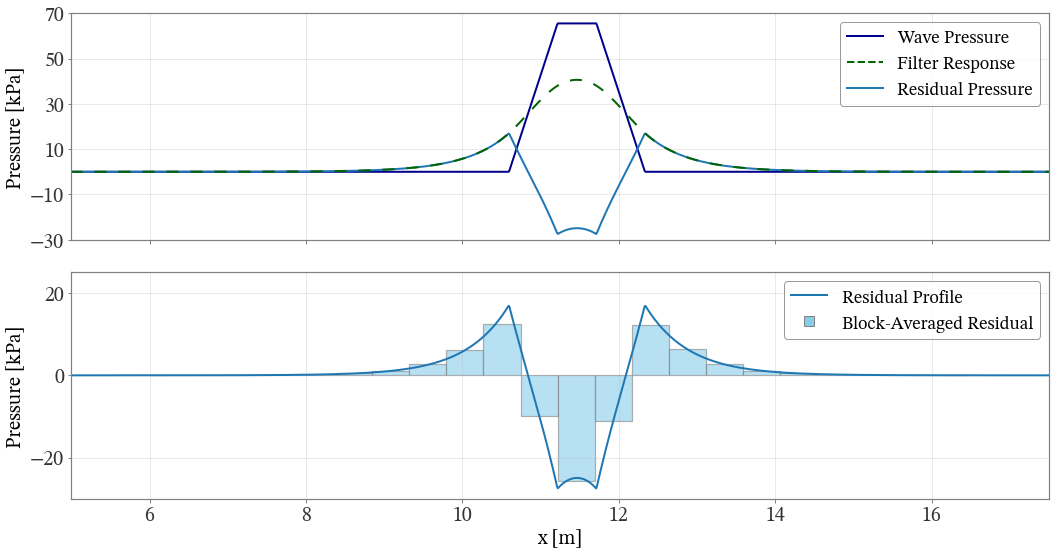

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from matplotlib.lines import Line2D

x=20
# --------- Thesis style (fonts, sizes, grid, saving) ---------
plt.rcParams.update({
    "font.family": "STIX Two Text",
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.titlesize": x,
    "axes.labelsize": x,
    "xtick.labelsize": x,
    "ytick.labelsize": x,
    "legend.fontsize": x-2,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.2,
    "axes.grid": True,
    "grid.linestyle": "-",
    "grid.alpha": 0.35,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# -------------------------
# Example data setup
# -------------------------
Hs = 0.8
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.3
k_prime = 0.015
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate top wave only ---
n = 1000
p_values = [(k + 1) / float(n + 1) for k in range(1)]  # only highest wave
wave_heights = sorted([round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

wave_pressures = {}
filter_responses = {}
residual_profiles = {}
block_pressures_per_wave = {}

for H_wave in wave_heights:
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[wave_name] = block_avg_pressures

highest_wave_name = list(wave_pressures.keys())[0]

# -----------------------------
# Shared X-axis Figure
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, facecolor='white')

# ---- Top subplot ----
ax1.plot(x, wave_pressures[highest_wave_name] / 1000.0, '-', lw=2, color='darkblue', label='Wave Pressure')
ax1.plot(x, residual_profiles[highest_wave_name] / 1000.0, '-', lw=2, color='tab:blue', label='Residual Pressure')
ax1.plot(x, filter_responses[highest_wave_name] / 1000.0, dashes=(6, 6), lw=2, color='darkgreen', label='Filter Response')


for spine in ax1.spines.values():
    spine.set_color('grey')
ax1.tick_params(colors='0.2')
ax1.tick_params(axis='both', which='both', color='0.4')
ax1.set_ylabel('Pressure [kPa]')
ax1.grid(True, linestyle='-', alpha=0.35)
ax1.legend(frameon=True, facecolor='white', edgecolor='grey')
ax1.set_xlim(5, 17.5)
ax1.set_ylim(-30, 70)
ax1.set_yticks(np.arange(-30, 71, 20))

# ---- Bottom subplot ----
residual_kPa = residual_profiles[highest_wave_name] / 1000.0
block_avg_pressures_kPa = np.array(block_pressures_per_wave[highest_wave_name]) / 1000.0

ax2.plot(x, residual_kPa, '', lw=2, color='tab:blue', label='Residual Profile')
ax2.bar(
    block_positions,
    block_avg_pressures_kPa,
    width=block_dx,
    align='edge',
    color='skyblue',
    edgecolor='grey',
    linewidth=1.2,
    alpha=0.6,
    label='Block-Averaged Residual'
)

for spine in ax2.spines.values():
    spine.set_color('grey')
ax2.tick_params(colors='0.2')
ax2.tick_params(axis='both', which='both', color='0.4')
ax2.set_xlabel('x [m]')
ax2.set_ylabel('Pressure [kPa]')
ax2.set_ylim(-30, 25)
ax2.set_yticks(np.arange(-20, 26, 20))
ax2.grid(True, linestyle='-', alpha=0.35)
# ---- Custom legend handles ----
custom_lines = [
    Line2D([0], [0], color='darkblue', lw=2, linestyle='-'),       # Wave Pressure
    Line2D([0], [0], color='darkgreen', lw=2, linestyle='--'),     # Filter Response (legend only shows dashed)
    Line2D([0], [0], color='tab:blue', lw=2, linestyle='-')        # Residual Pressure
]
ax1.legend(
    custom_lines,
    ['Wave Pressure', 'Filter Response', 'Residual Pressure'],
    frameon=True, facecolor='white', edgecolor='grey'
)
# Custom legend for bottom plot
custom_lines_bottom = [
    Line2D([0], [0], color='tab:blue', lw=2, linestyle='-'),       # Residual Profile
    Line2D([0], [0], color='skyblue', marker='s', markersize=10,
           markerfacecolor='skyblue', markeredgecolor='grey', linestyle='None')  # Block avg residual
]
ax2.legend(
    custom_lines_bottom,
    ['Residual Profile', 'Block-Averaged Residual'],
    frameon=True, facecolor='white', edgecolor='grey'
)

plt.tight_layout()
plt.savefig("pressure_plots.pdf")
plt.show()
